# Lime perturbations

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## Relevant libraries

In [33]:
import pickle

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from astroExplain.spectra.notebook import explain_reconstruction_score
from astroExplain.spectra.explanation import TellMeWhy
from astroExplain.spectra import clustering
from astroExplain.spectra.figures import different_explanations

from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData
from sdss.utils.managefiles import FileDirectory

meta = MetaData()

/home/elom/gdrive/career/portfolio/phd/00_phd_code/xai-astronomy/src/astroExplain/spectra/figures.py:52: SyntaxWarning: invalid escape sequence '\l'
  axs[-1].set_xlabel("$\lambda$ [$\AA$]")


## Custom functions

In [3]:
def explanation_name(lime_config: dict, fudge_config: dict) -> str:

    segmentation = lime_config["segmentation"]
    n_segments = lime_config["number_segments"]
    perturbation = fudge_config["kind_of_fudge"]

    explanation_str = f"{segmentation}_{n_segments}_{perturbation}"

    if perturbation == "scale":

        scale_factor = fudge_config["scale_factor"]
        explanation_str = f"{explanation_str}_{scale_factor}"

    return explanation_str

## Weights unit normalization

In [27]:
def unit_norm_weights(
    wave, spectrum,
    score_config,
    lime_config,
    fudge_config,
    ae_model
)-> np.ndarray:
    (
        explanation,
        ret_exp_score,
        ret_exp_local_pred
    ) = explain_reconstruction_score(
        wave=wave, spectrum=spectrum,
        score_config=score_config,
        lime_config=lime_config,
        fudge_config=fudge_config,
        model=ae_model
    )

    why = TellMeWhy(wave=wave, explanation=explanation)

    weights = why.get_heatmap().reshape(1, -1)

    weights = clustering.normalize_weights_l2_abs(weights)
    weights = weights.reshape(-1)
    return weights, why


# Data ingestion

In [4]:
data_dir = "/home/elom/spectra"
model_dir = "/home/elom/models"
bin_id = "bin_03"
explanations_dir = f"{model_dir}/{bin_id}/explanation"
paper_figures_dir = "/home/elom/phd/00_paper_explain-me-why/sections/figures/"

In [ ]:
meta_data_df = pd.read_csv(
    f"{data_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

In [5]:
wave = np.load(f"{data_dir}/wave_spectra_imputed.npy")

spectra = np.load(
    f"{data_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

idx_id = np.load(
    f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)

## Load model

In [6]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{model_dir}/{bin_id}",
)

# Baseline explanation

In [30]:
broad_near_halpha = {
    'specobjid': 2664004586678806528,
    'metric': 'mse_filter_250kms_noRel97',
    'explanation': 'uniform_64_scale_0.9',
}
specobjid = broad_near_halpha["specobjid"]
idx_spectrum = specobjid_to_idx(specobjid, idx_id)
spectrum = spectra[idx_spectrum]


Set explainer and Get explanations
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2664004586678806528&apid=


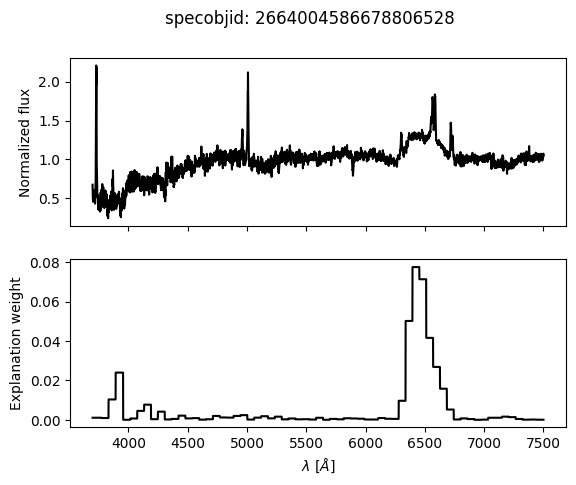

In [31]:
# config file
score_config = {
    "metric": "mse",
    "velocity": 250,
    # if reconstruction
    "relative": False,
    "percentage": 100,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}
lime_config = {
    "segmentation": "uniform",
    "number_segments": 64,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}
fudge_config = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 1.2,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}



weights, why = unit_norm_weights(
    wave, spectrum,
    score_config,
    lime_config,
    fudge_config,
    ae_model
)

fig, axs = why.plot_full_explanation(figure_size=None)

axs[0].plot(why.wave, why.galaxy, c="black")
axs[0].set_ylabel("Normalized flux")

max_weight = np.nanmax(weights)

max_norm_weights = False

if max_norm_weights:
    weights /= max_weight

axs[1].plot(
    why.wave, weights, color="black"
)
axs[1].set_ylabel("Explanation weight")
axs[1].set_xlabel(r"$\lambda$ [$\AA$]")

fig.suptitle(f"specobjid: {specobjid}")

print(meta.get_sky_server_url(specobjid))

# Different perturbations

In [32]:
weights_perturbations = []
whys_perturbations = []

kind_of_fudge = "scale"
fudge_config["kind_of_fudge"] = kind_of_fudge
scale_factors = [0.6, 0.9, 1.2]

for scale in scale_factors:

    fudge_config["scale_factor"] = scale

    weights, why = unit_norm_weights(
        wave, spectrum,
        score_config,
        lime_config,
        fudge_config,
        ae_model
    )

    weights_perturbations.append(weights)
    whys_perturbations.append(why)


Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


0.10207010119078241


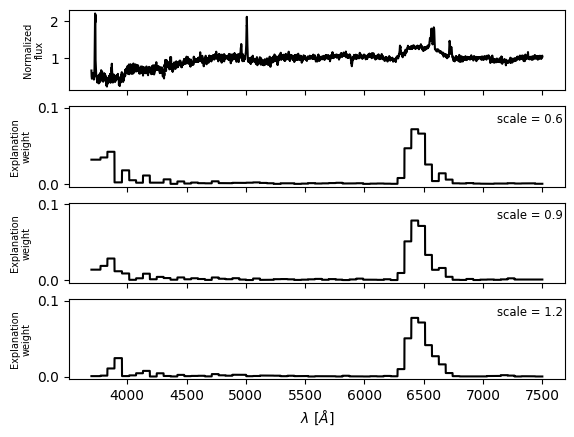

In [41]:
scale_labels = [f"scale = {factor}" for factor in scale_factors]

fig, axs = plt.subplots(
    nrows=1 + len(scale_factors),
    ncols=1,
    sharex=True,
)

font_size = 7.0
axs[0].plot(wave, spectrum, c="black")
axs[0].set_ylabel("Normalized\nflux", fontsize=font_size)

overall_max_weight = np.nanmax(weights_perturbations)
overall_max_weight += 0.3*overall_max_weight

for idx, weights in enumerate(weights_perturbations):

    axs[idx + 1].plot(
        wave,
        weights,
        color="black",
        label=scale_labels[idx],
    )
    axs[idx + 1].set_ylabel("Explanation\nweight", fontsize=font_size)
    
    axs[idx + 1].set_ylim(ymax=overall_max_weight)

axs[-1].set_xlabel(r"$\lambda$ [$\AA$]")

for idx, scale in enumerate(scale_labels):
    axs[idx + 1].text(
        0.93,
        0.84,
        scale,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        fontsize="small",
    )
print(overall_max_weight)

# Ignore

In [2]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from anomaly.constants import GALAXY_LINES
from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData
from sdss.utils.managefiles import FileDirectory
from anomaly.utils import specobjid_to_idx
from anomaly.utils import set_intersection
from astroExplain.spectra.utils import get_anomaly_score_name
from astroExplain.spectra.notebook import explanation_name
from astroExplain.spectra.notebook import interpret
from astroExplain.spectra.notebook import explain_reconstruction_score
from astroExplain.spectra.figures import different_explanations

meta = MetaData()
%matplotlib inline

In [3]:
# config
bin_id = "bin_04"
model_id = "0013"
architecture = "256_128_64/latent_12"
meta_data_directory = "/home/edgar/spectra/0_01_z_0_5_4_0_snr_inf"
model_directory = (
    f"{meta_data_directory}/{bin_id}/models/{architecture}/{model_id}"
)
explanations_directory = (
    f"{meta_data_directory}/{bin_id}/explanation/{architecture}"
)
scores_directory = (
    f"{meta_data_directory}/bin_04/explanation/256_128_64/latent_12"
)

In [4]:
# load data
wave = np.load(f"{meta_data_directory}/wave.npy")
meta_data_df = pd.read_csv(
    f"{meta_data_directory}/0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)
model = AutoEncoder(reload=True, reload_from=model_directory)
spectra = np.load(f"{meta_data_directory}/spectra.npy", mmap_mode="r")
idx_id = np.load(
    f"{meta_data_directory}/{bin_id}/{bin_id}_index_specobjid.npy"
)

In [5]:
# anomaly score
score_config = {
    "metric": "mse",
    "velocity": 250,
    # if reconstruction
    "relative": True,
    "percentage": 97,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

In [6]:
# spectrum
specobjid = 2664004586678806528
idx_spectrum = specobjid_to_idx(specobjid, idx_id)
spectrum = spectra[idx_spectrum]
# plt.plot(wave, spectrum)

### Original explanation

Set explainer and Get explanations
Get heat map of explanation
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2664004586678806528&apid=


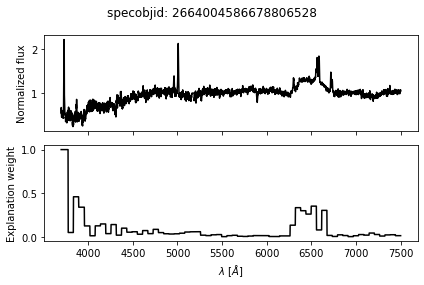

In [7]:
lime_config = {
    "segmentation": "uniform",
    "number_segments": 64,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}
fudge_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 1.0,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": False,
    "kernel_size": 3,
    "sigma": 0,
}

explanation = explain_reconstruction_score(
    wave, spectrum, score_config, lime_config, fudge_config, model
)

fig, axs = interpret(
    wave, explanation=explanation, positive=0, negative=0, figsize=None
)
print(meta.get_sky_server_url(specobjid))

fig.suptitle(f"specobjid: {specobjid}")
fig.tight_layout()

save_to = "/home/edgar/explain-me-why/sections/figures/explanations"
FileDirectory.check_directory(save_to, exit_program=False)
explanation_Str = explanation_name(lime_config, fudge_config)

# fig.savefig(
#     f"{save_to}/{specobjid}_{anomaly_from_score}_{explanation_Str}.pdf"
# )

## Perturbation

Set explainer and Get explanations
Get heat map of explanation
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2664004586678806528&apid=


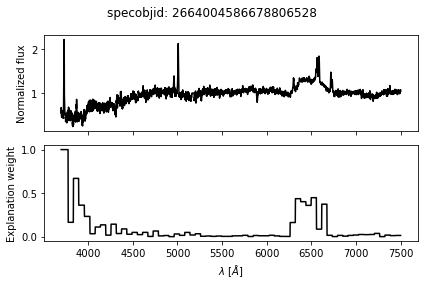

In [10]:
lime_config = {
    "segmentation": "uniform",
    "number_segments": 64,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}
fudge_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 0.9,
    # gaussians
    "amplitude": 0.1,
    "sigmas_in_segment": 10,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0.0,
}

explanation = explain_reconstruction_score(
    wave, spectrum, score_config, lime_config, fudge_config, model
)

fig, axs = interpret(
    wave, explanation=explanation, positive=0, negative=0, figsize=None
)
print(meta.get_sky_server_url(specobjid))

fig.suptitle(f"specobjid: {specobjid}")
fig.tight_layout()

save_to = "/home/edgar/explain-me-why/sections/figures/perturbation"
FileDirectory.check_directory(save_to, exit_program=False)
explanation_str = explanation_name(lime_config, fudge_config)
n_samples = lime_config["number_samples"]

# fig.savefig(
#     f"{save_to}/{explanation_str}_samples_{n_samples}.pdf"
# )

In [9]:
explanations = []
# kind_of_fudge = "scale"
# fudge_config["kind_of_fudge"] = kind_of_fudge
# scale_factors = [0.6, 0.9, 1.2]
# for scale in scale_factors:

#     fudge_config["scale_factor"] = scale

#     explanation = explain_reconstruction_score(
#         wave, spectrum,
#         score_config, lime_config, fudge_config,
#         model
#     )

#     explanations.append(explanation)

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


Get heat map of explanation
Get heat map of explanation
Get heat map of explanation


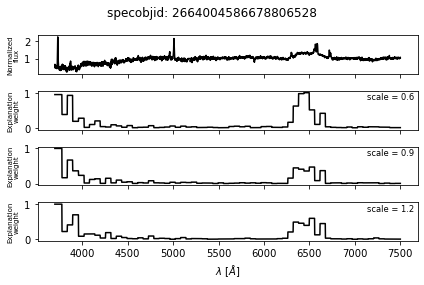

In [68]:
scale_labels = [f"scale = {factor}" for factor in scale_factors]

fig, axs = different_explanations(
    wave=wave, explanations=explanations, figsize=None, labels=scale_labels
)
for idx, scale in enumerate(scale_labels):
    axs[idx + 1].text(
        0.93,
        0.84,
        scale,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        fontsize="small",
    )
fig.suptitle(f"specobjid: {specobjid}")
fig.savefig(f"{save_to}/{specobjid}_scale_perturbations.pdf")

Flat perturbation

In [11]:
explanations = []

kind_of_fudge = "flat"
fudge_config["kind_of_fudge"] = kind_of_fudge
flat_factors = [0.9, 1.0, 1.1]

for flat in flat_factors:

    fudge_config["continuum"] = flat

    explanation = explain_reconstruction_score(
        wave, spectrum, score_config, lime_config, fudge_config, model
    )

    explanations.append(explanation)

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


Get heat map of explanation
Get heat map of explanation
Get heat map of explanation


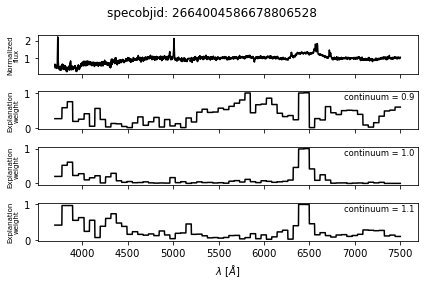

In [15]:
flat_labels = [f"continuum = {factor}" for factor in flat_factors]

fig, axs = different_explanations(
    wave=wave, explanations=explanations, figsize=None, labels=flat_labels
)
for idx, flat in enumerate(flat_labels):
    axs[idx + 1].text(
        0.9,
        0.84,
        flat,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        fontsize="small",
    )
fig.suptitle(f"specobjid: {specobjid}")
fig.savefig(f"{save_to}/{specobjid}_flat_perturbations.pdf")

## Samples

Set explainer and Get explanations
Get heat map of explanation
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2664004586678806528&apid=


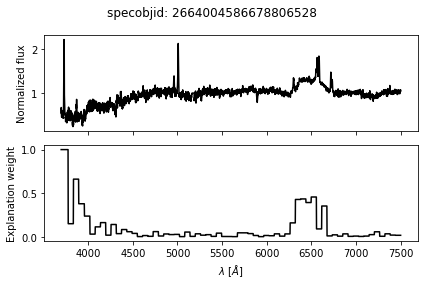

In [70]:
lime_config = {
    "segmentation": "uniform",
    "number_segments": 64,
    "number_samples": 1000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}
fudge_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 1.0,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}
explanation = explain_reconstruction_score(
    wave, spectrum, score_config, lime_config, fudge_config, model
)

fig, axs = interpret(
    wave, explanation=explanation, positive=0, negative=0, figsize=None
)
print(meta.get_sky_server_url(specobjid))

fig.suptitle(f"specobjid: {specobjid}")
fig.tight_layout()

save_to = "/home/edgar/explain-me-why/sections/figures/segmentation"
FileDirectory.check_directory(save_to, exit_program=False)
explanation_str = explanation_name(lime_config, fudge_config)
n_samples = lime_config["number_samples"]

# fig.savefig(
#     f"{save_to}/{explanation_str}_samples_{n_samples}.pdf"
# )

In [71]:
explanations = []

number_samples = [10, 100, 1000]

for n_samples in number_samples:

    lime_config["number_samples"] = n_samples

    explanation = explain_reconstruction_score(
        wave, spectrum, score_config, lime_config, fudge_config, model
    )

    explanations.append(explanation)

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


Get heat map of explanation
Get heat map of explanation
Get heat map of explanation


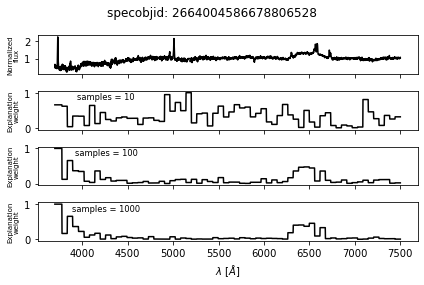

In [77]:
samples_labels = [f"samples = {factor}" for factor in number_samples]

fig, axs = different_explanations(
    wave=wave, explanations=explanations, figsize=None, labels=flat_labels
)
for idx, n_samples in enumerate(samples_labels):
    axs[idx + 1].text(
        0.18,
        0.84,
        n_samples,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        fontsize="small",
    )
fig.suptitle(f"specobjid: {specobjid}")
fig.savefig(f"{save_to}/{specobjid}_n_samples.pdf")

## Segmentation

Set explainer and Get explanations
69
Get heat map of explanation
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2664004586678806528&apid=


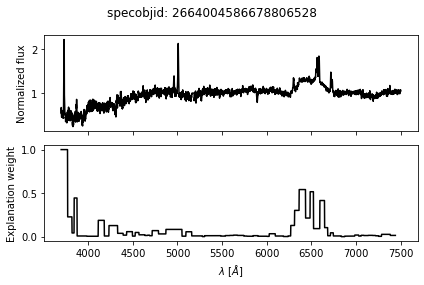

In [67]:
lime_config = {
    "segmentation": "kmeans",
    "number_segments": 100,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}
fudge_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 1.0,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}
explanation = explain_reconstruction_score(
    wave, spectrum, score_config, lime_config, fudge_config, model
)
print(np.unique(explanation.segments).size)
fig, axs = interpret(
    wave, explanation=explanation, positive=0, negative=0, figsize=None
)
print(meta.get_sky_server_url(specobjid))

fig.suptitle(f"specobjid: {specobjid}")
fig.tight_layout()

save_to = "/home/edgar/explain-me-why/sections/figures/segmentation"
FileDirectory.check_directory(save_to, exit_program=False)
explanation_str = explanation_name(lime_config, fudge_config)
n_samples = lime_config["number_samples"]

# fig.savefig(
#     f"{save_to}/{explanation_str}_samples_{n_samples}.pdf"
# )

Number of segments in uniform segmentation

In [68]:
explanations = []
number_segments = [10, 100, 1000]
lime_config["segmentation"] = "kmeans"

for n_segments in number_segments:

    lime_config["number_segments"] = n_segments

    explanation = explain_reconstruction_score(
        wave, spectrum, score_config, lime_config, fudge_config, model
    )

    explanations.append(explanation)

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


Get heat map of explanation
Get heat map of explanation
Get heat map of explanation


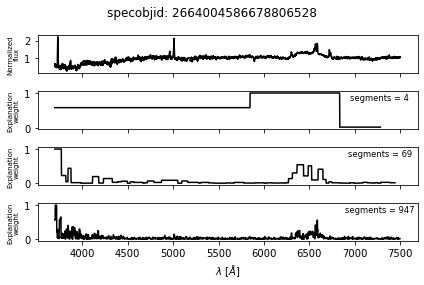

In [69]:
# segments_labels = [
#     f"segments = {factor}" for factor in number_segments
# ]
segments_labels = [f"segments = {factor}" for factor in [4, 69, 947]]

fig, axs = different_explanations(
    wave=wave, explanations=explanations, figsize=None, labels=flat_labels
)
for idx, n_segments in enumerate(segments_labels):
    axs[idx + 1].text(
        0.9,
        0.84,
        n_segments,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        fontsize="small",
    )
fig.suptitle(f"specobjid: {specobjid}")
fig.savefig(
    f"{save_to}/{specobjid}_n_segments_" f"{lime_config['segmentation']}.pdf"
)

### Flat perturbation for string emission spectrum

Set explainer and Get explanations
Get heat map of explanation
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=637325355518027776&apid=


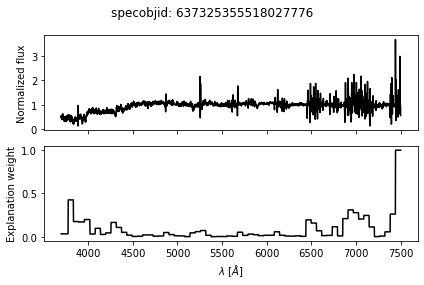

In [35]:
# config file
score_config = {
    "metric": "mse",
    "velocity": 0,
    # if reconstruction
    "relative": 0,
    "percentage": 100,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}
lime_config = {
    "segmentation": "uniform",
    "number_segments": 64,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}
fudge_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "flat",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 1.0,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}
# Load data frame with anomalies
anomaly_from_score = "mse_noRel100"
anomalies_df = pd.read_csv(
    f"{explanations_directory}/{anomaly_from_score}/top_anomalies.csv.gz",
    index_col="specobjid",
)
# -22, 94
specobjid = anomalies_df.index[-94]
idx_spectrum = specobjid_to_idx(specobjid, idx_id)
spectrum = spectra[idx_spectrum]

explanation = explain_reconstruction_score(
    wave, spectrum, score_config, lime_config, fudge_config, model
)

fig, axs = interpret(
    wave, explanation=explanation, positive=0, negative=0, figsize=None
)
print(meta.get_sky_server_url(specobjid))

fig.suptitle(f"specobjid: {specobjid}")
fig.tight_layout()

save_to = "/home/edgar/explain-me-why/sections/figures/perturbation"
FileDirectory.check_directory(save_to, exit_program=False)
explanation_str = explanation_name(lime_config, fudge_config)

# fig.savefig(
#     f"{save_to}/{specobjid}_{anomaly_from_score}_{explanation_str}.pdf"
# )